# 0. Data Layers Overview

This notebook covers two things:

1. **Data architecture** — how the project's two base layers are structured and used.
2. **Dataset card** — statistics for a NeurIPS-style dataset section: domain coverage, resolution rates, temporal scope, and market-universe composition.

The two base layers are:

- `raw` — base input tables from `polymarket_export` / SQLite, with minimal research interpretation.
- `canonical` — normalized, stable research-facing layer for downstream representations.

Raw layer tables:
- `market_universe`, `selected_markets`, `added_markets`, `probabilities`, `raw_trades`, raw external covariates.

## Imports and configuration

In [17]:
# from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from polymarket_research.data.canonical import CanonicalDatasetBuilder
from polymarket_research.data.raw import RawExternalCovariates, RawPolymarketHandle
from polymarket_research.utils import setup_root

REPO_ROOT = setup_root()
RAW_CACHE_DIR = REPO_ROOT / 'research_notebooks' / 'running_artefacts_new'
CANONICAL_CACHE_DIR = RAW_CACHE_DIR / 'canonical_dataset'

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', None)


## Load the raw layer

The raw layer is accessed through a `RawPolymarketHandle`, which can materialize a `RawPolymarketBundle` either from live SQLite or from a parquet snapshot. `probabilities`, the download manifest, and `raw_trades` are all optional so this notebook can still run under lighter configurations.


In [2]:
USE_PARQUET_CACHE = (
    (RAW_CACHE_DIR / 'selected_markets.parquet').exists()
    and (RAW_CACHE_DIR / 'probabilities.parquet').exists()
) and False
MARKET_LIMIT = None
MARKET_ORDER = None  # one of: None, 'latest', 'largest'
INCLUDE_PROBABILITIES = True
INCLUDE_DOWNLOAD_MANIFEST = True
INCLUDE_RAW_TRADES = False
SAVE_RAW_SNAPSHOT = True

raw_handle = RawPolymarketHandle(cache_dir=RAW_CACHE_DIR)

if USE_PARQUET_CACHE:
    print('Loading raw bundle from parquet snapshot')
    raw_bundle = raw_handle.snapshot().load_bundle(
        include_download_manifest=INCLUDE_DOWNLOAD_MANIFEST,
        include_raw_trades=INCLUDE_RAW_TRADES,
        market_limit=MARKET_LIMIT,
        market_order=MARKET_ORDER,
    )
    raw_source_label = f'parquet snapshot: {RAW_CACHE_DIR}'
else:
    raw_bundle = raw_handle.load_bundle(
        include_market_universe=True,
        include_download_manifest=INCLUDE_DOWNLOAD_MANIFEST,
        include_probabilities=INCLUDE_PROBABILITIES,
        include_raw_trades=INCLUDE_RAW_TRADES,
        market_limit=MARKET_LIMIT,
        market_order=MARKET_ORDER,
    )
    if SAVE_RAW_SNAPSHOT:
        raw_handle.snapshot().save_bundle(raw_bundle)
    raw_source_label = f'sqlite: {raw_handle.db_path}'

raw_external = RawExternalCovariates().load()

print('Raw source:', raw_source_label)
print('Market limit:', MARKET_LIMIT)
print('Market order:', MARKET_ORDER)
print('External cached path:', raw_external.path)
print('Probabilities eagerly loaded:', raw_bundle.probabilities is not None)
print('Download manifest eagerly loaded:', raw_bundle.added_markets is not None)
print('Raw trades eagerly loaded:', raw_bundle.raw_trades is not None)

market_universe = raw_bundle.market_universe
selected_markets = raw_bundle.selected_markets
added_markets = raw_bundle.added_markets
probabilities = raw_bundle.probabilities
raw_trades = raw_bundle.raw_trades

display(raw_bundle.summary())
display(raw_external.summary())


Raw source: sqlite: /Users/sneddy/research/polymarket_research/db/resolved_probability_dataset.sqlite
Market limit: None
Market order: None
External cached path: /Users/sneddy/research/polymarket_research/cached_data/external_covariates
Probabilities eagerly loaded: True
Download manifest eagerly loaded: True
Raw trades eagerly loaded: False


,name,loaded,rows,cols
0,market_universe,True,17247,33
1,selected_markets,True,17247,34
2,added_markets,True,10159,14
3,probabilities,True,93504504,7
4,raw_trades,False,0,0


,name,loaded,rows,cols
0,external_covariates,True,263808,19


## Quick inspection of raw tables

In [3]:
display(Markdown('### Raw selected markets'))
display(raw_bundle.short_markets.head(10))

display(Markdown('### Raw market universe'))
display(market_universe[['market_id', 'event_title', 'question', 'created_at', 'end_date']].head(10))

display(Markdown('### Raw download manifest'))
if added_markets is None:
    display(pd.DataFrame({'note': ['download manifest not eagerly loaded in this run']}))
else:
    display(added_markets[['market_id', 'probability_rows', 'raw_trade_rows', 'raw_trades_saved', 'added_at_utc']].head(10))

display(Markdown('### Raw probabilities'))
if probabilities is None:
    display(pd.DataFrame({'note': ['probabilities not eagerly loaded in this run']}))
else:
    display(probabilities.head(10))

display(Markdown('### Raw trades'))
if raw_trades is None:
    display(pd.DataFrame({'note': ['raw_trades not eagerly loaded in this run']}))
else:
    display(raw_bundle.short_raw_trades.head(10))

display(Markdown('### Raw external covariates'))
display(raw_external.short_covariates.head(10))


### Raw selected markets

,market_id,event_id,event_slug,event_title,event_series_slug,question,primary_domain,active,closed,resolved,probability_start_utc,probability_end_utc,raw_trade_rows,raw_trades_saved,final_outcome
0,1914442,355927,what-will-hegseth-say-during-press-conference-on-april-8,What will Hegseth say during press conference on April 8?,NaN,"Will Hegseth say ""AI"" or ""Cyber"" during press conference?",unassigned,0,1,True,2026-04-08 14:55:00+00:00,2026-04-08 19:05:00+00:00,34.0,1.0,No
1,1912875,355362,north-korea-missile-testlaunch-by-april-30-2026,"North Korea missile test/launch by April 30, 2026?",north-korea-missile-launch,"North Korea missile test/launch by April 30, 2026?",unassigned,0,1,False,2026-04-08 00:00:00+00:00,2026-04-08 09:10:00+00:00,369.0,1.0,Yes
2,1912772,355299,trump-announces-us-x-iran-ceasefire-by,Trump announces US x Iran ceasefire end by...?,NaN,"Trump announces US x Iran ceasefire end by April 8, 2026?",unassigned,0,1,True,2026-04-08 17:25:00+00:00,2026-04-09 06:50:00+00:00,401.0,1.0,No
3,1912494,236840,us-x-iran-ceasefire-by,US x Iran ceasefire by...?,NaN,US x Iran ceasefire by April 10?,unassigned,0,1,False,2026-04-07 22:05:00+00:00,2026-04-08 01:15:00+00:00,2887.0,1.0,Yes
4,1908626,354273,trump-announces-hormuz-deadline-extension-today,Trump announces Hormuz deadline extension today?,NaN,Trump announces Hormuz deadline extension today?,unassigned,0,1,True,2026-04-07 16:45:00+00:00,2026-04-08 00:45:00+00:00,13503.0,1.0,Yes
5,1900198,352298,chess-mblueb-jsinda-2026-04-08-r9,Matthias Bluebaum vs. Javokhir Sindarov - FIDE Candidates 2026 Open (Round 9),chess,Will Javokhir Sindarov win on 2026-04-08 at FIDE Candidates 2026 Open?,unassigned,0,1,False,2026-04-07 19:10:00+00:00,2026-04-08 18:50:00+00:00,561.0,1.0,No
6,1896585,236840,us-x-iran-ceasefire-by,US x Iran ceasefire by...?,NaN,US x Iran ceasefire by May 15?,unassigned,0,1,False,2026-04-06 21:35:00+00:00,2026-04-08 01:35:00+00:00,2812.0,1.0,Yes
7,1894667,351154,kanye-blocked-from-entering-the-uk-by-may-31,Kanye blocked from entering the UK by May 31?,NaN,Kanye blocked from entering the UK by May 31?,unassigned,0,1,False,2026-04-06 21:50:00+00:00,2026-04-07 16:15:00+00:00,553.0,1.0,Yes
8,1891746,350660,what-will-trump-say-during-bilateral-events-with-mark-rutte,What will Trump say during bilateral events with Mark Rutte?,NaN,"Will Trump say ""Strait"" or ""Hormuz"" during events with Rutte?",unassigned,0,1,True,2026-04-06 15:55:00+00:00,2026-04-09 06:10:00+00:00,1329.0,1.0,No
9,1891024,350426,will-ye-be-dropped-as-wireless-headliner,Will Ye be dropped as Wireless Headliner?,NaN,Will Ye be dropped as Wireless Headliner?,unassigned,0,1,False,2026-04-06 19:50:00+00:00,2026-04-07 17:00:00+00:00,379.0,1.0,Yes


### Raw market universe

,market_id,event_title,question,created_at,end_date
0,1914442,What will Hegseth say during press conference on April 8?,"Will Hegseth say ""AI"" or ""Cyber"" during press conference?",2026-04-08 03:11:44.253910+00:00,2026-04-08 00:00:00+00:00
1,1912875,"North Korea missile test/launch by April 30, 2026?","North Korea missile test/launch by April 30, 2026?",2026-04-07 22:57:59.405799+00:00,2026-04-30 00:00:00+00:00
2,1912772,Trump announces US x Iran ceasefire end by...?,"Trump announces US x Iran ceasefire end by April 8, 2026?",2026-04-07 22:29:26.052957+00:00,2026-04-08 00:00:00+00:00
3,1912494,US x Iran ceasefire by...?,US x Iran ceasefire by April 10?,2026-04-07 21:50:59.559310+00:00,2026-04-10 00:00:00+00:00
4,1908626,Trump announces Hormuz deadline extension today?,Trump announces Hormuz deadline extension today?,2026-04-07 15:40:22.404315+00:00,2026-04-07 00:00:00+00:00
5,1900198,Matthias Bluebaum vs. Javokhir Sindarov - FIDE Candidates 2026 Open (Round 9),Will Javokhir Sindarov win on 2026-04-08 at FIDE Candidates 2026 Open?,2026-04-07 02:00:05.230299+00:00,2026-04-15 12:45:00+00:00
6,1896585,US x Iran ceasefire by...?,US x Iran ceasefire by May 15?,2026-04-06 21:22:28.129696+00:00,2026-05-15 00:00:00+00:00
7,1894667,Kanye blocked from entering the UK by May 31?,Kanye blocked from entering the UK by May 31?,2026-04-06 18:34:37.075782+00:00,2026-05-31 00:00:00+00:00
8,1891746,What will Trump say during bilateral events with Mark Rutte?,"Will Trump say ""Strait"" or ""Hormuz"" during events with Rutte?",2026-04-06 15:35:08.836854+00:00,2026-04-08 00:00:00+00:00
9,1891024,Will Ye be dropped as Wireless Headliner?,Will Ye be dropped as Wireless Headliner?,2026-04-06 13:57:21.017803+00:00,2026-07-10 00:00:00+00:00


### Raw download manifest

...

,market_id,timestamp_utc,yes_probability,observed_trade,trade_count,total_size,last_trade_price
0,1001804,2025-12-23 18:20:00+00:00,0.11,1,2,10.0,0.89
1,1001804,2025-12-23 18:25:00+00:00,0.11,0,0,0.0,NaN
2,1001804,2025-12-23 18:30:00+00:00,0.11,0,0,0.0,NaN
3,1001804,2025-12-23 18:35:00+00:00,0.11,0,0,0.0,NaN
4,1001804,2025-12-23 18:40:00+00:00,0.11,0,0,0.0,NaN
5,1001804,2025-12-23 18:45:00+00:00,0.11,0,0,0.0,NaN
6,1001804,2025-12-23 18:50:00+00:00,0.11,0,0,0.0,NaN
7,1001804,2025-12-23 18:55:00+00:00,0.11,0,0,0.0,NaN
8,1001804,2025-12-23 19:00:00+00:00,0.11,0,0,0.0,NaN
9,1001804,2025-12-23 19:05:00+00:00,0.11,0,0,0.0,NaN


### Raw trades

,note
0,raw_trades not eagerly loaded in this run


### Raw external covariates

,series_id,timestamp_utc,close_timestamp_utc,open,high,low,close,volume,quote_asset_volume,trade_count
0,btc_usd,2025-01-01 00:00:00+00:00,2025-01-01 00:04:59.999000+00:00,93576.00,93702.15,93537.50,93661.20,45.94160,4.301907e+06,7448
1,btc_usd,2025-01-01 00:05:00+00:00,2025-01-01 00:09:59.999000+00:00,93661.20,93678.02,93600.00,93607.10,71.94585,6.736121e+06,4165
2,btc_usd,2025-01-01 00:10:00+00:00,2025-01-01 00:14:59.999000+00:00,93607.10,93656.19,93489.03,93656.18,57.96928,5.423766e+06,8175
3,btc_usd,2025-01-01 00:15:00+00:00,2025-01-01 00:19:59.999000+00:00,93656.19,93840.05,93614.95,93796.35,39.74456,3.727084e+06,8031
4,btc_usd,2025-01-01 00:20:00+00:00,2025-01-01 00:24:59.999000+00:00,93796.35,93898.05,93707.81,93740.00,38.38053,3.600685e+06,10064
5,btc_usd,2025-01-01 00:25:00+00:00,2025-01-01 00:29:59.999000+00:00,93740.00,93761.90,93721.00,93761.90,17.29240,1.620905e+06,2383
6,btc_usd,2025-01-01 00:30:00+00:00,2025-01-01 00:34:59.999000+00:00,93761.90,93963.67,93761.89,93882.92,41.20105,3.868314e+06,9193
7,btc_usd,2025-01-01 00:35:00+00:00,2025-01-01 00:39:59.999000+00:00,93882.91,93924.61,93836.61,93909.03,29.61201,2.779744e+06,7252
8,btc_usd,2025-01-01 00:40:00+00:00,2025-01-01 00:44:59.999000+00:00,93909.03,93952.97,93885.00,93885.01,23.55110,2.211784e+06,5380
9,btc_usd,2025-01-01 00:45:00+00:00,2025-01-01 00:49:59.999000+00:00,93885.00,93977.98,93864.44,93977.97,16.06620,1.509070e+06,3953


## Raw layer: market universe activity

,week,weekly_volume_proxy
57,2026-02-02,1.303068e+08
58,2026-02-09,1.009540e+08
59,2026-02-16,1.900212e+08
60,2026-02-23,1.719404e+08
61,2026-03-02,1.337091e+08
62,2026-03-09,5.965755e+07
63,2026-03-16,2.965132e+08
64,2026-03-23,1.272795e+07
65,2026-03-30,4.931849e+06
66,2026-04-06,2.525658e+06


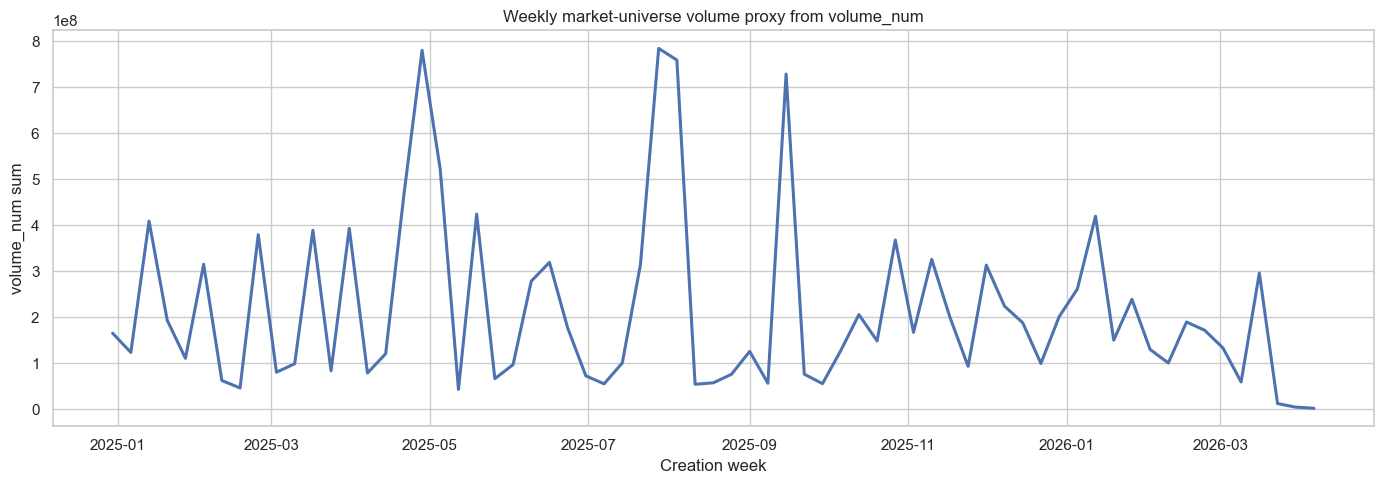

In [4]:
universe_weekly_volume = (
    market_universe.assign(
        week=market_universe['created_at'].dt.tz_localize(None).dt.to_period('W').dt.start_time,
        volume_num=market_universe['volume_num'].fillna(0.0),
    )
    .groupby('week', as_index=False)['volume_num']
    .sum()
    .rename(columns={'volume_num': 'weekly_volume_proxy'})
)

display(universe_weekly_volume.tail(10))

plt.figure(figsize=(14, 5))
plt.plot(universe_weekly_volume['week'], universe_weekly_volume['weekly_volume_proxy'], linewidth=2.2, color='#4c72b0')
plt.title('Weekly market-universe volume proxy from volume_num')
plt.ylabel('volume_num sum')
plt.xlabel('Creation week')
plt.tight_layout()
plt.show()


## Raw layer: export download coverage snapshot

,selected_market_scope
0,17247


,metric,markets,share_pct
0,with_added_market_row,10159,58.902998
1,with_probabilities,10159,58.902998
2,with_raw_trades,10113,58.636285
3,complete,10105,58.589900
4,pending,7142,41.410100


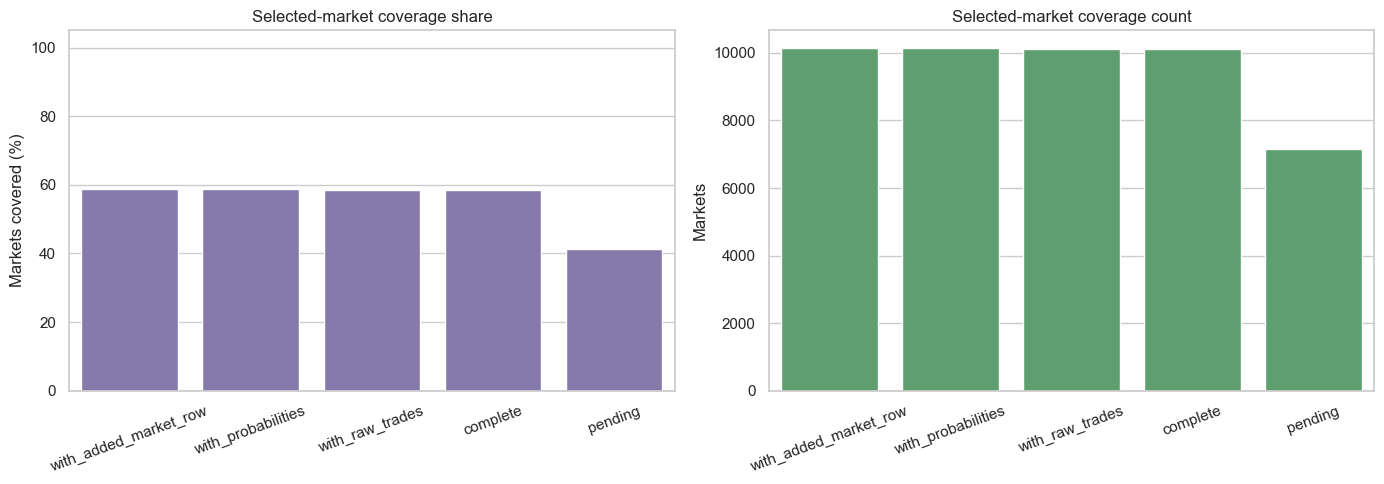

In [5]:
if added_markets is None:
    display(pd.DataFrame({'note': ['download coverage requires include_download_manifest=True']}))
else:
    selected_scope = selected_markets[['market_id', 'created_at']].drop_duplicates().copy()
    status_frame = selected_scope.merge(
        added_markets[['market_id', 'probability_rows', 'raw_trade_rows', 'raw_trades_saved']],
        on='market_id', how='left'
    )

    if probabilities is None:
        status_frame['observed_probability_rows'] = 0
    else:
        probability_counts = probabilities.groupby('market_id', as_index=False).size().rename(columns={'size': 'observed_probability_rows'})
        status_frame = status_frame.merge(probability_counts, on='market_id', how='left')

    status_frame['has_added_market_row'] = (
        status_frame['probability_rows'].notna()
        | status_frame['raw_trade_rows'].notna()
        | status_frame['raw_trades_saved'].notna()
    )
    status_frame['has_probabilities'] = status_frame['observed_probability_rows'].fillna(0).gt(0)
    status_frame['raw_trades_saved'] = status_frame['raw_trades_saved'].fillna(0).astype(int)
    status_frame['has_raw_trades'] = status_frame['raw_trade_rows'].fillna(0).gt(0)
    status_frame['is_complete'] = (
        status_frame['has_probabilities']
        & status_frame['raw_trades_saved'].eq(1)
        & status_frame['has_raw_trades']
    )
    status_frame['is_pending'] = ~status_frame['is_complete']

    coverage_summary = pd.DataFrame({
        'metric': ['with_added_market_row', 'with_probabilities', 'with_raw_trades', 'complete', 'pending'],
        'markets': [
            int(status_frame['has_added_market_row'].sum()),
            int(status_frame['has_probabilities'].sum()),
            int(status_frame['has_raw_trades'].sum()),
            int(status_frame['is_complete'].sum()),
            int(status_frame['is_pending'].sum()),
        ],
    })
    coverage_summary['share_pct'] = 100.0 * coverage_summary['markets'] / len(status_frame)

    display(pd.DataFrame([{'selected_market_scope': len(status_frame)}]))
    display(coverage_summary)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(data=coverage_summary, x='metric', y='share_pct', color='#8172b2', ax=axes[0])
    axes[0].set_title('Selected-market coverage share')
    axes[0].set_ylabel('Markets covered (%)')
    axes[0].set_xlabel('')
    axes[0].set_ylim(0, 105)
    axes[0].tick_params(axis='x', rotation=20)

    sns.barplot(data=coverage_summary, x='metric', y='markets', color='#55a868', ax=axes[1])
    axes[1].set_title('Selected-market coverage count')
    axes[1].set_ylabel('Markets')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()


## Raw layer: downloaded trading activity

,week,weekly_share_volume_proxy
55,2026-02-02,7.520123e+08
56,2026-02-09,6.410871e+08
57,2026-02-16,5.068578e+08
58,2026-02-23,1.075807e+09
59,2026-03-02,4.592473e+08
60,2026-03-09,3.358862e+08
61,2026-03-16,3.518880e+08
62,2026-03-23,3.447466e+08
63,2026-03-30,4.307229e+08
64,2026-04-06,4.862604e+08


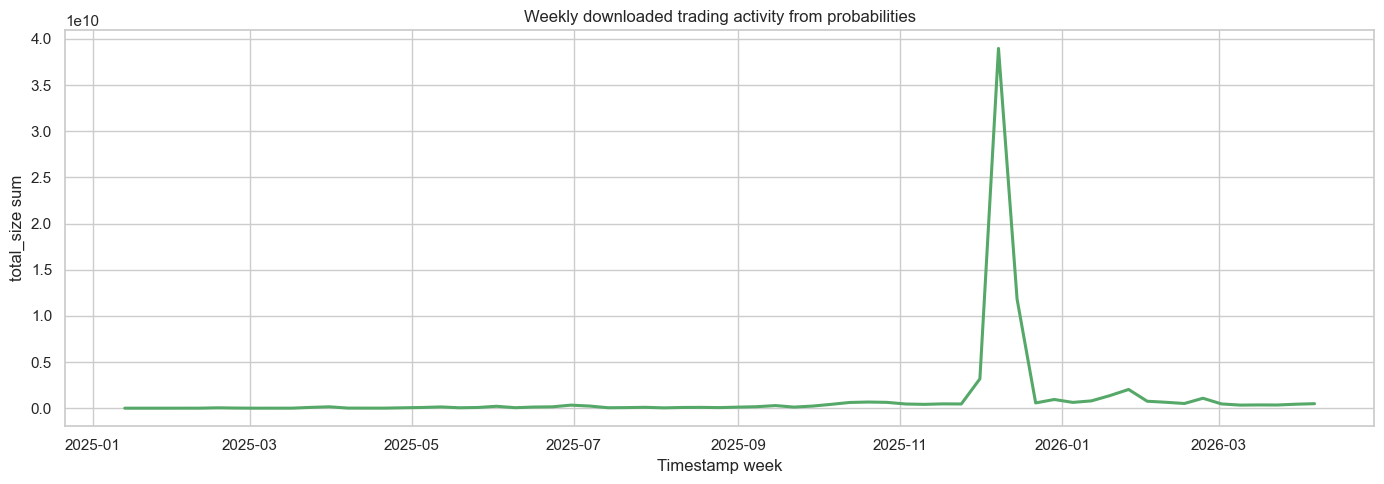

In [6]:
if probabilities is None:
    display(pd.DataFrame({'note': ['downloaded trading activity requires include_probabilities=True']}))
else:
    probability_weekly = (
        probabilities.assign(
            week=probabilities['timestamp_utc'].dt.tz_localize(None).dt.to_period('W').dt.start_time,
            total_size=probabilities['total_size'].fillna(0.0),
        )
        .groupby('week', as_index=False)['total_size']
        .sum()
        .rename(columns={'total_size': 'weekly_share_volume_proxy'})
    )

    display(probability_weekly.tail(10))

    plt.figure(figsize=(14, 5))
    plt.plot(probability_weekly['week'], probability_weekly['weekly_share_volume_proxy'], linewidth=2.2, color='#55a868')
    plt.title('Weekly downloaded trading activity from probabilities')
    plt.ylabel('total_size sum')
    plt.xlabel('Timestamp week')
    plt.tight_layout()
    plt.show()


## Raw external layer

,series_id,rows,start,end,mean_close
0,btc_usd,131904,2025-01-01 00:00:00+00:00,2026-04-03 23:55:00+00:00,96507.921255
1,eth_usd,131904,2025-01-01 00:00:00+00:00,2026-04-03 23:55:00+00:00,2931.216081


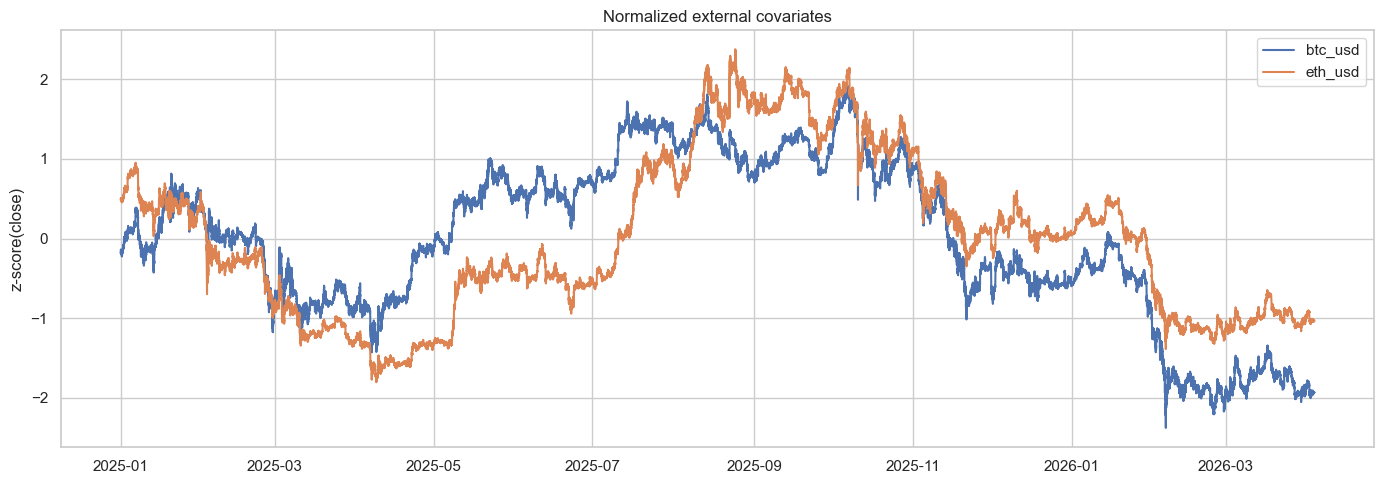

In [7]:
external_stats = (
    raw_external.covariates.groupby('series_id', as_index=False)
    .agg(
        rows=('timestamp_utc', 'size'),
        start=('timestamp_utc', 'min'),
        end=('timestamp_utc', 'max'),
        mean_close=('close', 'mean'),
    )
)
display(external_stats)

plot_cov = raw_external.covariates[['series_id', 'timestamp_utc', 'close']].dropna().copy()
plot_cov['z_close'] = plot_cov.groupby('series_id')['close'].transform(lambda s: (s - s.mean()) / s.std())

plt.figure(figsize=(14, 5))
for series_id, frame in plot_cov.groupby('series_id'):
    plt.plot(frame['timestamp_utc'], frame['z_close'], label=series_id, linewidth=1.5)
plt.title('Normalized external covariates')
plt.ylabel('z-score(close)')
plt.legend()
plt.tight_layout()
plt.show()


## Canonical layer

Now we build the canonical dataset on top of the raw layer. This is not a new data source; it is a stable normalized layer for downstream representations. If `probabilities` are not materialized in the current raw bundle, the canonical probability panel will simply be empty in this run.


In [8]:
canonical = CanonicalDatasetBuilder(
    raw_dataset=raw_bundle,
    raw_external=raw_external,
    resolved_only=True,
).build()
canonical_manifest = canonical.save(CANONICAL_CACHE_DIR)

print('Canonical cache:', CANONICAL_CACHE_DIR)
display(canonical.summary())
display(canonical.status())
display(canonical_manifest)
display(canonical.markets[['market_id', 'question', 'domain', 'family_id', 'resolved']].head(10))
if canonical.download_status is None or canonical.download_status.empty:
    display(pd.DataFrame({'note': ['canonical download_status is empty for this run']}))
else:
    display(
        canonical.download_status[
            ['market_id', 'has_added_market_row', 'has_probabilities', 'has_raw_trades', 'raw_trades_saved', 'is_complete']
        ].head(10)
    )


Canonical cache: /Users/sneddy/research/polymarket_research/research_notebooks/running_artefacts_new/canonical_dataset


,name,rows,cols
0,markets,15662,36
1,probabilities,79455705,7
2,external_covariates,263808,19
3,download_status,17247,16


,scope,selected_markets,with_added_markets,with_probabilities,with_raw_trades,raw_trades_saved,complete_markets,pending_markets
0,all,17247,10159,10159,10113,10105,10105,7142


,file,rows,cols
0,markets.parquet,15662,36
1,probabilities.parquet,79455705,7
2,external_covariates.parquet,263808,19
3,download_status.parquet,17247,16


,market_id,question,domain,family_id,resolved
0,1914442,"Will Hegseth say ""AI"" or ""Cyber"" during press conference?",unassigned,unassigned::::hegseth say ai or cyber during,True
1,1912772,"Trump announces US x Iran ceasefire end by April 8, 2026?",unassigned,unassigned::::trump announces us x iran ceasefire,True
2,1908626,Trump announces Hormuz deadline extension today?,unassigned,unassigned::::trump announces hormuz deadline extension today,True
3,1891746,"Will Trump say ""Strait"" or ""Hormuz"" during events with Rutte?",unassigned,unassigned::::trump say strait or hormuz during,True
4,1882888,Will Trump's remarks not air?,unassigned,unassigned::::trump s remarks not air,True
5,1882870,"Will Trump say ""Biden"" during Monday news conference?",unassigned,unassigned::::trump say biden during monday news,True
6,1882867,"Will Trump say ""Fuck"" or ""Fucking"" during Monday news conference?",unassigned,unassigned::::trump say fuck or fucking during,True
7,1882865,"Will Trump say ""Easter"" or ""Egg"" during Monday news conference?",unassigned,unassigned::::trump say easter or egg during,True
8,1882863,"Will Trump say ""Pilot"" or ""Crew"" or ""Staff"" 5+ times during Monday news conference?",unassigned,unassigned::::trump say pilot or crew or,True
9,1882861,"Will Trump say ""Iran"" or ""Iranian"" 15+ times during Monday news conference?",unassigned,unassigned::::trump say iran or iranian 15,True


,market_id,has_added_market_row,has_probabilities,has_raw_trades,raw_trades_saved,is_complete
0,572236,False,False,False,0,False
1,572234,False,False,False,0,False
2,572233,False,False,False,0,False
3,572222,False,False,False,0,False
4,572193,False,False,False,0,False
5,572192,False,False,False,0,False
6,572191,False,False,False,0,False
7,572190,False,False,False,0,False
8,572189,False,False,False,0,False
9,572188,False,False,False,0,False


## Filesystem workflow

The canonical layer has a symmetric filesystem lifecycle. Below we verify a reload from the saved snapshot.

In [9]:
canonical_reloaded = canonical.from_parquet(CANONICAL_CACHE_DIR)

display(pd.DataFrame([
    {'object': 'canonical_reloaded_markets', 'rows': len(canonical_reloaded.markets), 'cols': canonical_reloaded.markets.shape[1]},
    {'object': 'canonical_reloaded_probabilities', 'rows': len(canonical_reloaded.probabilities), 'cols': canonical_reloaded.probabilities.shape[1]},
]))


,object,rows,cols
0,canonical_reloaded_markets,15662,36
1,canonical_reloaded_probabilities,79455705,7


---

# Dataset Card

This section summarizes the resolved-market sample used downstream: temporal coverage, market duration, outcome balance, family concentration, and how much probability history is actually available for modeling.


In [10]:
# Use the canonical resolved-market scope for all dataset card statistics.
markets = canonical.markets.copy()
probs = canonical.probabilities.copy()

prob_start = str(probs['timestamp_utc'].min().date()) if not probs.empty else None
prob_end = str(probs['timestamp_utc'].max().date()) if not probs.empty else None

display(Markdown('### Resolved market scope'))
display(pd.DataFrame([{
    'total_resolved_markets': len(markets),
    'total_probability_rows': len(probs),
    'unique_market_ids_in_probs': 0 if probs.empty else probs['market_id'].nunique(),
    'market_date_range_start': str(markets['created_at'].min().date()) if not markets.empty else None,
    'market_date_range_end': str(markets['end_date'].max().date()) if not markets.empty else None,
    'probability_date_range_start': prob_start,
    'probability_date_range_end': prob_end,
}]))


### Resolved market scope

,total_resolved_markets,total_probability_rows,unique_market_ids_in_probs,market_date_range_start,market_date_range_end,probability_date_range_start,probability_date_range_end
0,15662,79455705,8740,2025-01-01,2026-04-08,2025-01-17,2026-04-09


## Dataset card: temporal coverage

**How to read this chart:**

- **Stacked bars:** how many markets in the analysis sample *resolved* in each month, split by final outcome (`Yes` = green, `No` = orange).
- **Blue line:** how many markets in the analysis sample were *live during that month* (`created_at <= month <= end_date`). This is concurrent live inventory within the sample, not the full Polymarket universe.

Together they show the monthly resolution flow and the size of the sample's live market inventory over time.

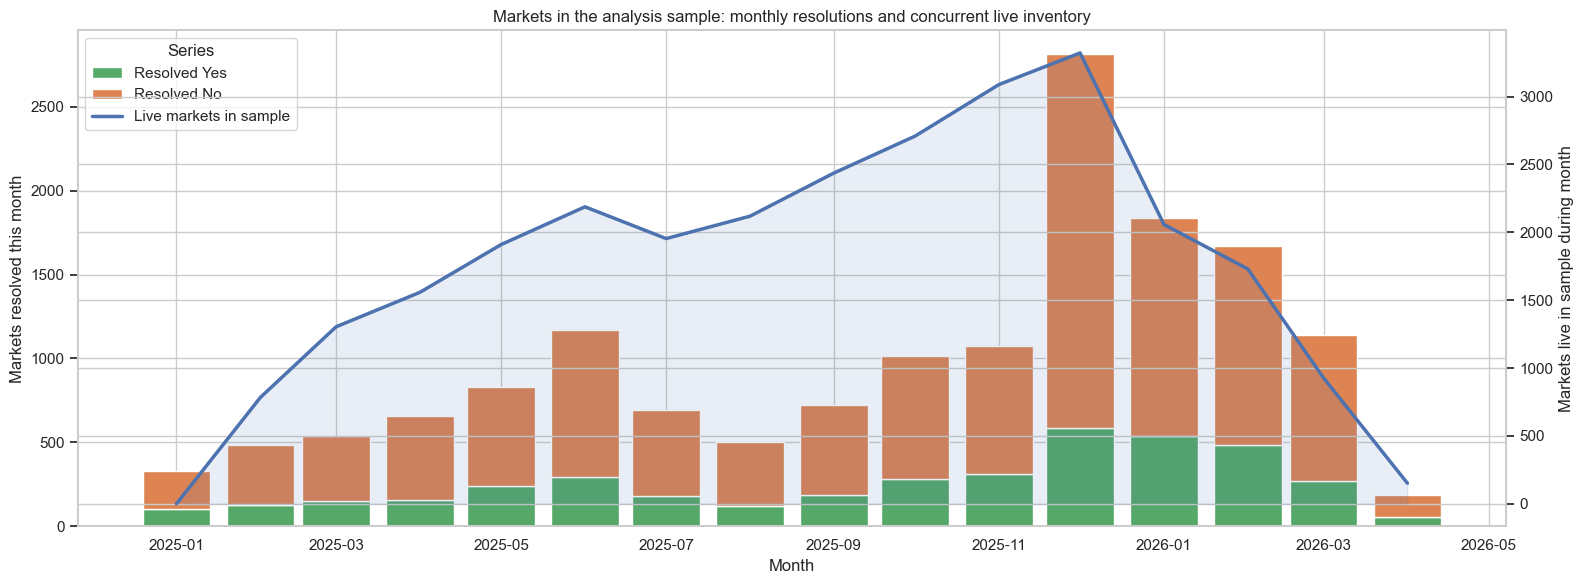

In [11]:
markets_temp = markets.copy()
markets_temp['final_outcome_num'] = pd.to_numeric(markets_temp['final_outcome'], errors='coerce')

for col in ['created_at', 'end_date']:
    markets_temp[col] = pd.to_datetime(markets_temp[col], utc=True, errors='coerce')

markets_temp = markets_temp.dropna(subset=['created_at', 'end_date'])
markets_temp['created_month'] = markets_temp['created_at'].dt.tz_localize(None).dt.to_period('M').dt.to_timestamp()
markets_temp['resolution_month'] = markets_temp['end_date'].dt.tz_localize(None).dt.to_period('M').dt.to_timestamp()

all_months = pd.date_range(
    markets_temp['created_month'].min(),
    markets_temp['resolution_month'].max(),
    freq='MS',
)

monthly_outcome = (
    markets_temp.groupby(['resolution_month', 'final_outcome'])
    .size()
    .unstack(fill_value=0)
    .reindex(all_months, fill_value=0)
)

created_arr = markets_temp['created_at'].dt.tz_localize(None).values
end_arr = markets_temp['end_date'].dt.tz_localize(None).values
active_series = pd.Series(
    [int(((created_arr <= m) & (end_arr >= m)).sum()) for m in all_months],
    index=all_months,
)

fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

yes_vals = monthly_outcome.get('Yes', pd.Series(0, index=all_months))
no_vals = monthly_outcome.get('No', pd.Series(0, index=all_months))

ax1.bar(all_months, yes_vals, width=25, color='#55a868', label='Resolved Yes')
ax1.bar(all_months, no_vals, bottom=yes_vals, width=25, color='#dd8452', label='Resolved No')

ax2.plot(all_months, active_series.values, color='#4c72b0', linewidth=2.5, label='Active markets')
ax2.fill_between(all_months, active_series.values, color='#4c72b0', alpha=0.12)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.set_title('Markets in the analysis sample: monthly resolutions and concurrent live inventory')
ax1.set_xlabel('Month')
ax1.set_ylabel('Markets resolved this month')
ax2.set_ylabel('Markets live in sample during month')

ax1.legend(
    handles1 + handles2,
    ['Resolved Yes', 'Resolved No', 'Live markets in sample'],
    loc='upper left',
    title='Series',
)

plt.tight_layout()
plt.show()


## Dataset card: market duration, trading activity, and snapshot coverage

These charts answer three concrete questions: how long markets stay live, how much trading activity they accumulate, and how complete the probability time series is relative to each market's lifetime.


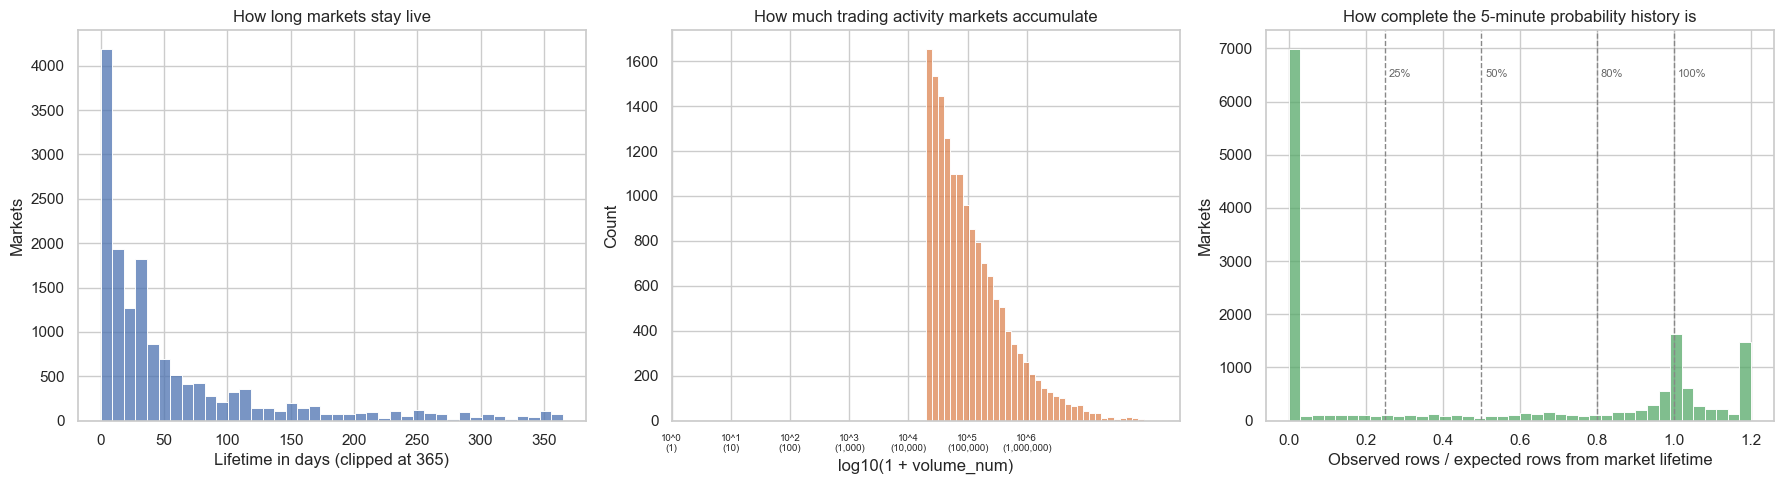

,median_lifetime_days,median_volume_num,median_snapshot_coverage_ratio,share_with_80pctplus_snapshot_coverage,share_with_95pctplus_snapshot_coverage
0,29.82,77213.26,0.283,0.384,0.332


In [12]:
markets['lifetime_days'] = ((markets['end_date'] - markets['created_at']).dt.total_seconds() / 86400.0)
markets['volume_num_clean'] = markets['volume_num'].fillna(0).clip(lower=0)
markets['probability_rows_clean'] = markets['probability_rows'].fillna(0).clip(lower=0)
markets['expected_rows_5m'] = (markets['lifetime_days'].clip(lower=0) * 288).clip(lower=1)
markets['coverage_ratio'] = (markets['probability_rows_clean'] / markets['expected_rows_5m']).replace([np.inf, -np.inf], np.nan)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(markets['lifetime_days'].dropna().clip(0, 365), bins=40, color='#4c72b0', ax=axes[0])
axes[0].set_title('How long markets stay live')
axes[0].set_xlabel('Lifetime in days (clipped at 365)')
axes[0].set_ylabel('Markets')

log10_volume = np.log10(markets['volume_num_clean'] + 1)
sns.histplot(log10_volume, bins=40, color='#dd8452', ax=axes[1])
axes[1].set_title('How much trading activity markets accumulate')
axes[1].set_xlabel('log10(1 + volume_num)')
tick_vals = [0, 1, 2, 3, 4, 5, 6]
axes[1].set_xticks(tick_vals)
axes[1].set_xticklabels([f'10^{v}\n({10**v:,})' for v in tick_vals], fontsize=7)

coverage = markets['coverage_ratio'].dropna().clip(0, 1.2)
sns.histplot(coverage, bins=40, color='#55a868', ax=axes[2])
axes[2].set_title('How complete the 5-minute probability history is')
axes[2].set_xlabel('Observed rows / expected rows from market lifetime')
axes[2].set_ylabel('Markets')
for ref, label in [(0.25, '25%'), (0.5, '50%'), (0.8, '80%'), (1.0, '100%')]:
    axes[2].axvline(ref, linestyle='--', linewidth=1, color='#888')
    axes[2].text(ref + 0.01, axes[2].get_ylim()[1] * 0.88, label, fontsize=8, color='#666')

plt.tight_layout()
plt.show()

display(pd.DataFrame([{
    'median_lifetime_days': round(markets['lifetime_days'].median(), 2),
    'median_volume_num': round(markets['volume_num_clean'].median(), 2),
    'median_snapshot_coverage_ratio': round(markets['coverage_ratio'].median(), 3),
    'share_with_80pctplus_snapshot_coverage': round((markets['coverage_ratio'] >= 0.8).mean(), 3),
    'share_with_95pctplus_snapshot_coverage': round((markets['coverage_ratio'] >= 0.95).mean(), 3),
}]))


## Dataset card: resolution outcomes and class balance over time

The overall Yes/No split matters, but the more informative question is whether class balance is stable over time or shifts month to month.


,label,count,share_pct
0,No,11578,73.924148
1,Yes,4084,26.075852


,total_markets,Yes,No,NaN / missing,overall_yes_rate
0,15662,4084,11578,0,0.261


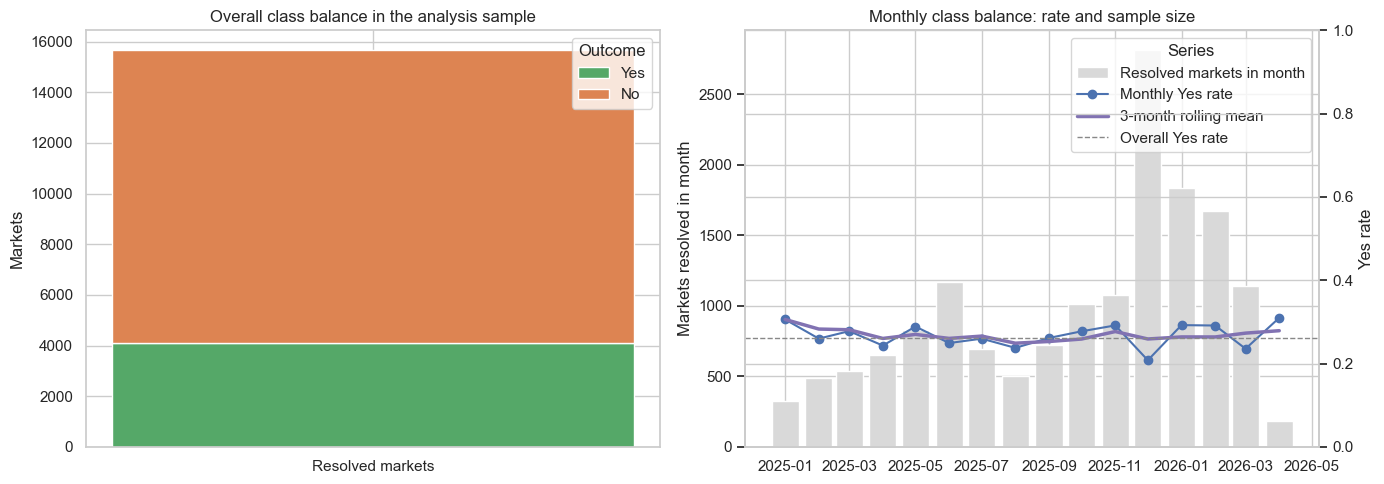

In [13]:
markets['final_outcome_num'] = markets['final_outcome'].map({'Yes': 1.0, 'No': 0.0})

outcome_counts = markets['final_outcome_num'].value_counts(dropna=False).reset_index()
outcome_counts.columns = ['final_outcome_num', 'count']
outcome_counts['label'] = outcome_counts['final_outcome_num'].map({1.0: 'Yes', 0.0: 'No'}).fillna('NaN / missing')
outcome_counts['share_pct'] = 100.0 * outcome_counts['count'] / outcome_counts['count'].sum()
display(outcome_counts[['label', 'count', 'share_pct']])

outcome_month = markets.dropna(subset=['final_outcome_num']).copy()
outcome_month['resolution_month'] = pd.to_datetime(outcome_month['end_date'], utc=True, errors='coerce').dt.tz_localize(None).dt.to_period('M').dt.to_timestamp()
monthly_yes = (
    outcome_month.groupby('resolution_month')
    .agg(
        n=('final_outcome_num', 'size'),
        yes_rate=('final_outcome_num', 'mean'),
    )
    .reset_index()
)
monthly_yes['yes_rate_3m'] = monthly_yes['yes_rate'].rolling(3, min_periods=1).mean()

n_yes = int((markets['final_outcome_num'] == 1.0).sum())
n_no = int((markets['final_outcome_num'] == 0.0).sum())
n_nan = int(markets['final_outcome_num'].isna().sum())
overall_yes_rate = n_yes / (n_yes + n_no) if (n_yes + n_no) > 0 else np.nan

display(pd.DataFrame([{
    'total_markets': len(markets),
    'Yes': n_yes,
    'No': n_no,
    'NaN / missing': n_nan,
    'overall_yes_rate': round(overall_yes_rate, 3),
}]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Resolved markets'], [n_yes], color='#55a868', label='Yes')
axes[0].bar(['Resolved markets'], [n_no], bottom=[n_yes], color='#dd8452', label='No')
axes[0].set_title('Overall class balance in the analysis sample')
axes[0].set_ylabel('Markets')
axes[0].legend(title='Outcome')

axes[1].bar(monthly_yes['resolution_month'], monthly_yes['n'], color='#d9d9d9', width=25, label='Resolved markets in month')
ax2 = axes[1].twinx()
ax2.plot(monthly_yes['resolution_month'], monthly_yes['yes_rate'], color='#4c72b0', linewidth=1.5, marker='o', label='Monthly Yes rate')
ax2.plot(monthly_yes['resolution_month'], monthly_yes['yes_rate_3m'], color='#8172b2', linewidth=2.5, label='3-month rolling mean')
ax2.axhline(overall_yes_rate, linestyle='--', color='#888', linewidth=1, label='Overall Yes rate')
axes[1].set_title('Monthly class balance: rate and sample size')
axes[1].set_ylabel('Markets resolved in month')
ax2.set_ylabel('Yes rate')
ax2.set_ylim(0, 1)
handles1, labels1 = axes[1].get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(handles1 + handles2, labels1 + labels2, loc='upper right', title='Series')

plt.tight_layout()
plt.show()


## Dataset card: terminal probability consistency

In this canonical layer, `final_yes_probability` should collapse to the resolved label at market end. This is less a calibration exercise than a consistency check that the terminal snapshot and final outcome agree.


,rows_checked,share_final_prob_eq_0,share_final_prob_eq_1,share_terminal_prob_matches_outcome_exactly,max_terminal_abs_error
0,15662,0.739,0.261,1.0,0.0


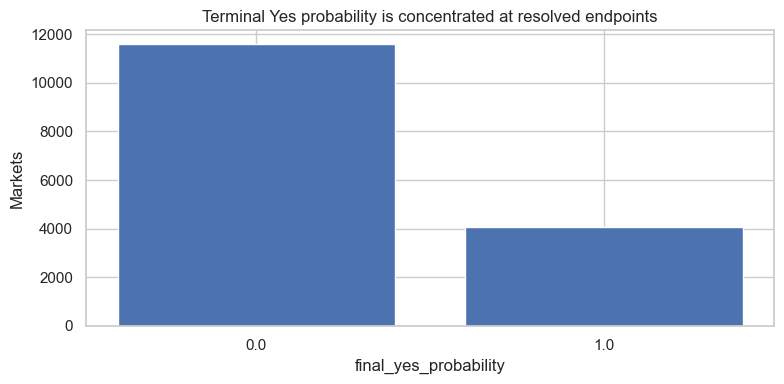

In [14]:
calibration_df = markets.copy()
calibration_df['final_yes_probability'] = pd.to_numeric(calibration_df['final_yes_probability'], errors='coerce')
calibration_df = calibration_df.dropna(subset=['final_outcome_num', 'final_yes_probability'])

if calibration_df.empty:
    display(Markdown('No rows with both `final_outcome` and `final_yes_probability` available for terminal consistency checks.'))
else:
    calibration_df['terminal_abs_error'] = (calibration_df['final_yes_probability'] - calibration_df['final_outcome_num']).abs()
    summary = pd.DataFrame([{
        'rows_checked': len(calibration_df),
        'share_final_prob_eq_0': round((calibration_df['final_yes_probability'] == 0).mean(), 3),
        'share_final_prob_eq_1': round((calibration_df['final_yes_probability'] == 1).mean(), 3),
        'share_terminal_prob_matches_outcome_exactly': round((calibration_df['terminal_abs_error'] == 0).mean(), 3),
        'max_terminal_abs_error': round(calibration_df['terminal_abs_error'].max(), 6),
    }])
    display(summary)

    fig, ax = plt.subplots(figsize=(8, 4))
    value_counts = calibration_df['final_yes_probability'].value_counts().sort_index()
    ax.bar(value_counts.index.astype(str), value_counts.values, color='#4c72b0')
    ax.set_title('Terminal Yes probability is concentrated at resolved endpoints')
    ax.set_xlabel('final_yes_probability')
    ax.set_ylabel('Markets')
    plt.tight_layout()
    plt.show()


## Dataset card: family structure and repeat-event concentration

These views answer whether the dataset is mostly singleton events or whether repeated market families dominate a substantial share of examples.


,total_families,singleton_families,singleton_market_share,markets_in_multi_market_families_share,median_family_size,mean_family_size,max_family_size,top_100_family_market_share
0,12697,11625,0.916,0.258,1.0,1.23,47,0.077


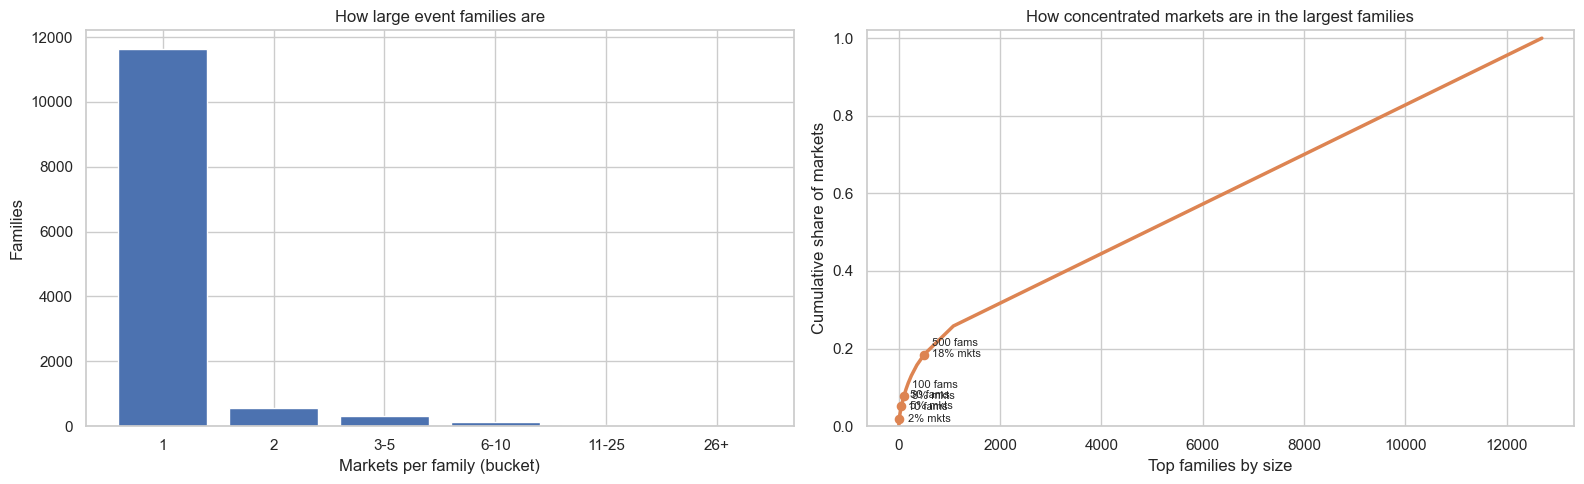

### Largest families

,family_id,family_size,family_rank,cum_market_share
0,unassigned::::trump say crypto or bitcoin during,47,1,0.003001
1,unassigned::::next us x venezuela military engagement,36,2,0.005299
2,unassigned::::elon musk s net worth between,36,3,0.007598
3,unassigned::::us next strike iran on march,31,4,0.009577
4,unassigned::::us next strike iran on february,28,5,0.011365
5,unassigned::::donald trump sign executive order on,24,6,0.012897
6,unassigned::::trump issue executive order on february,23,7,0.014366
7,unassigned::::trump announces new drug boat strike,21,8,0.015707
8,unassigned::::chatgpt 1 free app us apple,20,9,0.016984
9,unassigned::::us next strike iran on january,20,10,0.018261


In [15]:
family_sizes = markets.groupby('family_id').size().reset_index(name='family_size')
family_sizes = family_sizes.sort_values('family_size', ascending=False).reset_index(drop=True)
family_sizes['family_rank'] = np.arange(1, len(family_sizes) + 1)
family_sizes['cum_market_share'] = family_sizes['family_size'].cumsum() / family_sizes['family_size'].sum()

family_summary = pd.DataFrame([{
    'total_families': len(family_sizes),
    'singleton_families': int((family_sizes['family_size'] == 1).sum()),
    'singleton_market_share': round((family_sizes['family_size'] == 1).mean(), 3),
    'markets_in_multi_market_families_share': round((family_sizes.loc[family_sizes['family_size'] >= 2, 'family_size'].sum() / family_sizes['family_size'].sum()), 3),
    'median_family_size': family_sizes['family_size'].median(),
    'mean_family_size': round(family_sizes['family_size'].mean(), 2),
    'max_family_size': int(family_sizes['family_size'].max()),
    'top_100_family_market_share': round(family_sizes['family_size'].head(100).sum() / family_sizes['family_size'].sum(), 3),
}])
display(family_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

size_buckets = pd.cut(
    family_sizes['family_size'],
    bins=[0, 1, 2, 5, 10, 25, np.inf],
    labels=['1', '2', '3-5', '6-10', '11-25', '26+'],
    include_lowest=True,
)
bucket_counts = size_buckets.value_counts().sort_index()
axes[0].bar(bucket_counts.index.astype(str), bucket_counts.values, color='#4c72b0')
axes[0].set_title('How large event families are')
axes[0].set_xlabel('Markets per family (bucket)')
axes[0].set_ylabel('Families')

axes[1].plot(family_sizes['family_rank'], family_sizes['cum_market_share'], color='#dd8452', linewidth=2.5)
for ref in [10, 50, 100, 500]:
    if ref <= len(family_sizes):
        share = family_sizes.loc[ref - 1, 'cum_market_share']
        axes[1].scatter([ref], [share], color='#dd8452', s=35)
        axes[1].annotate(f'{ref} fams\n{share:.0%} mkts', (ref, share), textcoords='offset points', xytext=(6, -2), fontsize=8)
axes[1].set_title('How concentrated markets are in the largest families')
axes[1].set_xlabel('Top families by size')
axes[1].set_ylabel('Cumulative share of markets')
axes[1].set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

display(Markdown('### Largest families'))
display(family_sizes.head(15))


## Dataset card: probability-history support

If canonical probabilities are available, we inspect the raw distribution of observed 5-minute rows per market and then translate that into supported modeling horizons. Otherwise this section is skipped cleanly.


,horizon,min_rows,market_count,share_of_markets
0,1 hour,12,8737,0.558
1,1 day,288,8460,0.540
2,3 days,864,7748,0.495
3,1 week,2016,6165,0.394
4,2 weeks,4032,4763,0.304
5,1 month,8640,3232,0.206


,lifetime_bucket,markets,median_rows,median_coverage_ratio
0,<1d,421,162.0,1.262
1,1-7d,2878,470.5,0.507
2,8-30d,4236,1997.0,0.523
3,31-90d,4560,7576.5,0.531
4,91-365d,3256,0.0,0.000
5,365d+,4,0.0,0.000


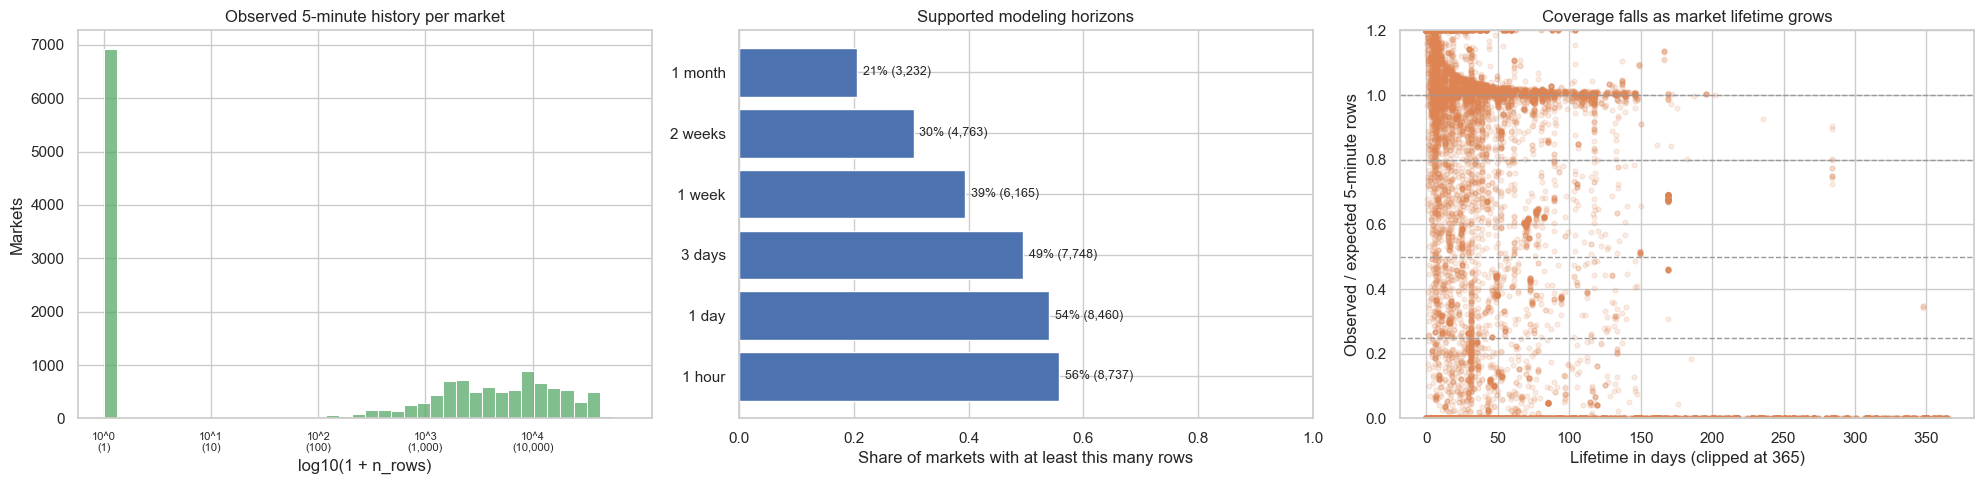

In [16]:
if probs.empty:
    display(pd.DataFrame({'note': ['canonical probability-history support is unavailable because no probabilities were materialized in this run']}))
else:
    probs_per_market = probs.groupby('market_id').size().reset_index(name='n_rows')
    density_df = markets[['market_id', 'lifetime_days', 'coverage_ratio']].merge(probs_per_market, on='market_id', how='left')
    density_df['n_rows'] = density_df['n_rows'].fillna(0)

    horizon_refs = pd.DataFrame({
        'horizon': ['1 hour', '1 day', '3 days', '1 week', '2 weeks', '1 month'],
        'min_rows': [12, 288, 864, 2016, 4032, 8640],
    })
    horizon_refs['market_count'] = horizon_refs['min_rows'].apply(lambda x: int((density_df['n_rows'] >= x).sum()))
    horizon_refs['share_of_markets'] = horizon_refs['market_count'] / len(density_df)
    display(horizon_refs.assign(share_of_markets=lambda df: df['share_of_markets'].round(3)))

    density_df['lifetime_bucket'] = pd.cut(
        density_df['lifetime_days'],
        bins=[0, 1, 7, 30, 90, 365, np.inf],
        labels=['<1d', '1-7d', '8-30d', '31-90d', '91-365d', '365d+'],
        include_lowest=True,
    )
    coverage_by_lifetime = (
        density_df.groupby('lifetime_bucket', observed=False)
        .agg(
            markets=('market_id', 'count'),
            median_rows=('n_rows', 'median'),
            median_coverage_ratio=('coverage_ratio', 'median'),
        )
        .reset_index()
    )
    display(coverage_by_lifetime.round(3))

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    log10_rows = np.log10(density_df['n_rows'] + 1)
    sns.histplot(log10_rows, bins=40, color='#55a868', ax=axes[0])
    axes[0].set_title('Observed 5-minute history per market')
    axes[0].set_xlabel('log10(1 + n_rows)')
    axes[0].set_ylabel('Markets')
    tick_vals = [0, 1, 2, 3, 4]
    axes[0].set_xticks(tick_vals)
    axes[0].set_xticklabels([f'10^{v}\n({10**v:,})' for v in tick_vals], fontsize=8)

    axes[1].barh(horizon_refs['horizon'], horizon_refs['share_of_markets'], color='#4c72b0')
    axes[1].set_title('Supported modeling horizons')
    axes[1].set_xlabel('Share of markets with at least this many rows')
    axes[1].set_xlim(0, 1)
    for i, row in horizon_refs.reset_index(drop=True).iterrows():
        axes[1].text(row['share_of_markets'] + 0.01, i, f"{row['share_of_markets']:.0%} ({row['market_count']:,})", va='center', fontsize=9)

    axes[2].scatter(
        density_df['lifetime_days'].clip(0, 365),
        density_df['coverage_ratio'].clip(0, 1.2),
        alpha=0.15,
        s=12,
        color='#dd8452',
    )
    axes[2].set_title('Coverage falls as market lifetime grows')
    axes[2].set_xlabel('Lifetime in days (clipped at 365)')
    axes[2].set_ylabel('Observed / expected 5-minute rows')
    axes[2].set_ylim(0, 1.2)
    for ref in [0.25, 0.5, 0.8, 1.0]:
        axes[2].axhline(ref, linestyle='--', linewidth=1, color='#999')

    plt.tight_layout()
    plt.show()


## Architectural boundary summary

Today the clean data architecture has three layers:

1. **Raw layer** — `market_universe`, `selected_markets`, `added_markets`, `probabilities`, `raw_trades`, raw external covariates.
2. **Canonical layer** — resolved filtering, internally consistent `markets` + `probabilities`, completeness-aware `status()`, typed timestamps, weak `family_id`, normalized text/tags, filesystem round-trip.
3. **Task / benchmark layer** — forecasting labels, masked reconstruction panels, repricing targets, paper-specific derived datasets.

This boundary keeps `polymarket_export` as the ingestion layer and `polymarket_research.data` as a reproducible research assembly on top.